# Notebook 03 — Layer 3: STT-Vergleich

**Ziel:** Die drei STT-Provider (Deepgram, Rev.ai, Azure) systematisch vergleichen: deskriptive Statistik, Verteilungs-Plots, zeitliche Stabilitaet, Warm-up-Verhalten, Beitrag des Verbindungs-Overheads zur Gesamtlatenz.

**Eingaben:** `data/processed/layer3_stt.parquet` (42.016 erfolgreiche Messungen)

**Metriken (siehe CLAUDE.md):**
- `connect_ms` — TCP+TLS+WS-Setup, kein Application-Verkehr
- `send_ms` — Audio-Upload (~5s WAV)
- `ttft_ms` — Time to First Token (erstes Transkript-Wort)
- `total_ms` — Gesamtdauer (incl. End-of-Stream + final transcript)

**Was wir aus NB 01+02 wissen:**
- Azure ist regional EU-nah (~10 ms RTT, TLS 1.3) → niedrigster Connect
- Deepgram USA, TLS 1.3 (~140 ms RTT), Anycast → mittlerer Connect (~437 ms)
- Rev.ai USA, TLS 1.2 (2-RTT-Handshake!) → hoechster Connect (~593 ms), zudem 10,16 % Connection-Failures

**Hypothese:** Bei `ttft_ms` sehen wir denselben Trend, aber der Abstand wird kleiner, weil Server-Processing-Zeit fuer die Spracherkennung dazu kommt — die ist eher modellabhaengig als infrastrukturabhaengig.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from _helpers import load_layer3, PROVIDER_COLORS, PROVIDER_REGION, save_figure, save_table

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.1f}')
sns.set_theme(style='whitegrid', context='notebook')

stt = load_layer3('stt')
print(f'Datensatz: {len(stt):,} Zeilen, {stt["api"].nunique()} Provider')
print('Provider:', sorted(stt['api'].unique()))
print('Zeitraum:', stt['ts'].min(), '->', stt['ts'].max())

STT_ORDER = ['azure', 'deepgram', 'revai']  # nach erwarteter Latenz sortiert
PALETTE = {p: PROVIDER_COLORS[p] for p in STT_ORDER}

Datensatz: 42,016 Zeilen, 3 Provider
Provider: ['azure', 'deepgram', 'revai']
Zeitraum: 2026-05-04 12:00:07.585414+00:00 -> 2026-05-22 12:27:54.854120+00:00


## 1. Deskriptive Statistik

Pro Provider und Metrik die wichtigsten Quantile.

**Warum Quantile statt Mean/Std:** RTT- und Latenzverteilungen sind in der Regel **rechtsschief** — die meisten Messungen liegen nah am Median, aber einzelne Ausreisser (z.B. ein verspaeteter Server, eine Netz-Schwankung) ziehen den Mean stark nach oben. p50 (Median) und p95 sagen mehr ueber die typische Erfahrung eines Nutzers als Mittelwert + Std.

Industrie-Standard fuer User-facing Latenz ist **p95** ("95 % der Calls sind schneller als X"). Fuer SLA-Klauseln wird oft **p99** genannt.

In [2]:
METRICS = ['connect_ms', 'send_ms', 'ttft_ms', 'total_ms']

def quantile_table(df, metrics):
    rows = []
    for api in STT_ORDER:
        sub = df[df['api']==api]
        for m in metrics:
            v = sub[m].dropna()
            rows.append({
                'provider': api, 'metric': m, 'n': len(v),
                'min': v.min(), 'p50': v.quantile(0.50),
                'p90': v.quantile(0.90), 'p95': v.quantile(0.95),
                'p99': v.quantile(0.99), 'max': v.max(),
                'mean': v.mean(), 'std': v.std(),
            })
    return pd.DataFrame(rows).set_index(['provider','metric']).round(1)

stats = quantile_table(stt, METRICS)
print(stats.to_string())
save_table(stats, '03_stt_statistics')

                         n     min     p50     p90     p95     p99      max    mean   std
provider metric                                                                          
azure    connect_ms  14500    43.1    48.4    62.0    74.5   262.1  5,055.9    56.7  69.6
         send_ms     14500    10.9    11.9    12.7    14.4    20.9    154.4    12.4   3.3
         ttft_ms     14500 1,712.8 1,718.7 1,723.3 1,725.4 1,730.6  2,527.7 1,719.7  14.3
         total_ms    14500 1,757.6 1,768.2 1,783.4 1,796.9 1,989.8  6,778.0 1,776.7  74.1
deepgram connect_ms  14489   313.2   437.0   473.9   480.0   544.5  4,610.1   426.0  93.9
         send_ms     14489   101.9   139.8   149.7   150.5   162.9  3,347.7   134.7  48.3
         ttft_ms     14489   412.1   587.0   659.8   694.2   851.3 17,807.2   593.1 379.5
         total_ms    14489 4,119.1 4,251.9 4,303.6 4,328.2 4,442.2 20,011.1 4,257.9 342.9
revai    connect_ms  13027   563.0   592.7   623.9   633.6   653.5  1,632.7   598.0  24.1
         s

## 2. Verteilungs-Visualisierung

Drei komplementaere Sichten auf dieselben Daten:

- **Violin-Plot:** zeigt die Form der Verteilung (Bimodalitaet? Long-Tail?). Breitenmass = Kernel-Density-Estimate.
- **Box-Plot:** zeigt Median + IQR + Whisker robust, gut zum Vergleich der "Mitte".
- **CDF-Plot:** zeigt "X % der Calls liegen unter Y ms" direkt ablesbar. Industrie-Standard fuer SLA-Diskussionen.

  saved figures/03_stt/{png,pdf}/03_stt_violin


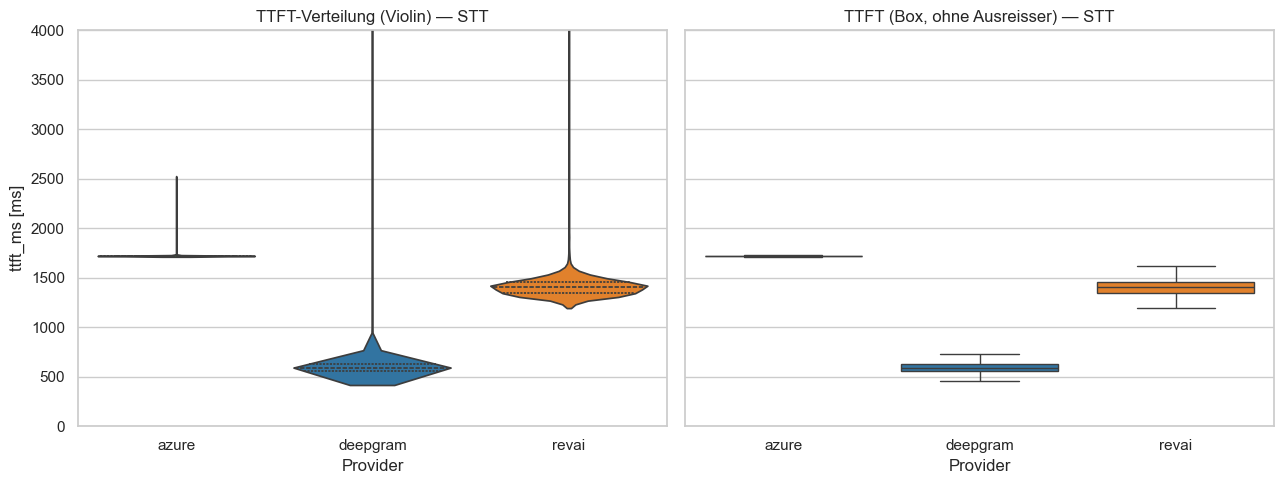

In [3]:
# Violin/Box-Plots fuer ttft_ms — die zentrale User-facing Metrik
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

sns.violinplot(data=stt, x='api', y='ttft_ms', order=STT_ORDER,
                hue='api', palette=PALETTE, legend=False, ax=axes[0], cut=0, inner='quartile')
axes[0].set_title('TTFT-Verteilung (Violin) — STT')
axes[0].set_xlabel('Provider')
axes[0].set_ylabel('ttft_ms [ms]')
axes[0].set_ylim(0, 4000)  # cut off extreme outliers fuer Lesbarkeit

sns.boxplot(data=stt, x='api', y='ttft_ms', order=STT_ORDER,
             hue='api', palette=PALETTE, legend=False, ax=axes[1], showfliers=False)
axes[1].set_title('TTFT (Box, ohne Ausreisser) — STT')
axes[1].set_xlabel('Provider')
axes[1].set_ylabel('')

plt.tight_layout()
save_figure(fig, '03_stt_violin')
plt.show()

C:\Users\anton\AppData\Local\Temp\ipykernel_6304\550649305.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


  saved figures/03_stt/{png,pdf}/03_stt_cdf


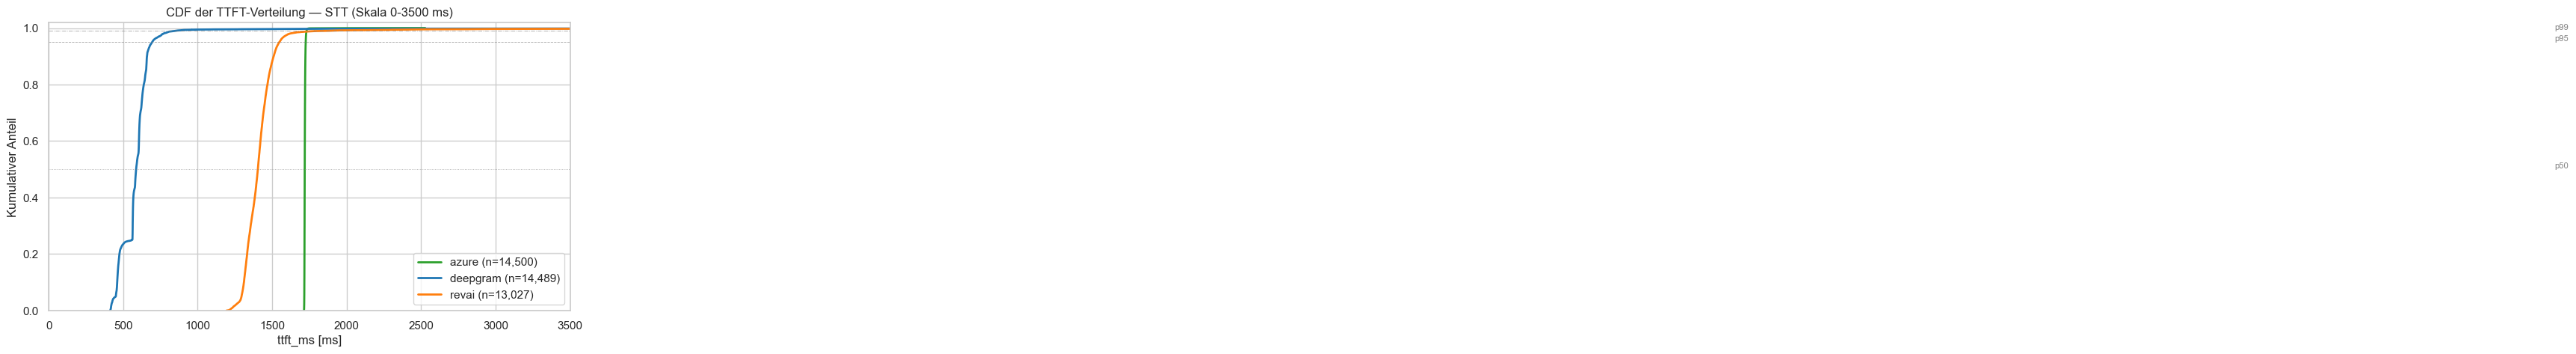

In [4]:
# CDF Plot: "Anteil der Calls die schneller als X ms sind"
fig, ax = plt.subplots(figsize=(9, 5))
for api in STT_ORDER:
    v = np.sort(stt[stt['api']==api]['ttft_ms'].dropna().values)
    y = np.arange(1, len(v)+1) / len(v)
    ax.plot(v, y, label=f'{api} (n={len(v):,})', color=PALETTE[api], linewidth=2)

# Referenzlinien bei p50, p95, p99
for pct, ls in [(0.50, ':'), (0.95, '--'), (0.99, '-.')]:
    ax.axhline(pct, color='gray', linestyle=ls, linewidth=0.6, alpha=0.7)
    ax.text(stt['ttft_ms'].max()*0.95, pct+0.005, f'p{int(pct*100)}', color='gray', fontsize=8, ha='right')

ax.set_xlim(0, 3500)
ax.set_ylim(0, 1.02)
ax.set_xlabel('ttft_ms [ms]')
ax.set_ylabel('Kumulativer Anteil')
ax.set_title('CDF der TTFT-Verteilung — STT (Skala 0-3500 ms)')
ax.legend(loc='lower right')
plt.tight_layout()
save_figure(fig, '03_stt_cdf')
plt.show()

## 3. Zeitliche Stabilitaet

**3a. Heatmap Stunde × Wochentag** — zeigt typische Variation ueber die Woche. Z.B. ob US-Office-Hours die Latenz beeinflussen (sollte bei guter Provider-Infrastruktur nicht).

**3b. Linienplot Median-TTFT pro Tag ueber 18 Tage** — Drift-Erkennung. Sollte flach verlaufen, sonst hat sich Server-/Routing-Verhalten geaendert.

  saved figures/03_stt/{png,pdf}/03_stt_heatmap_zeit


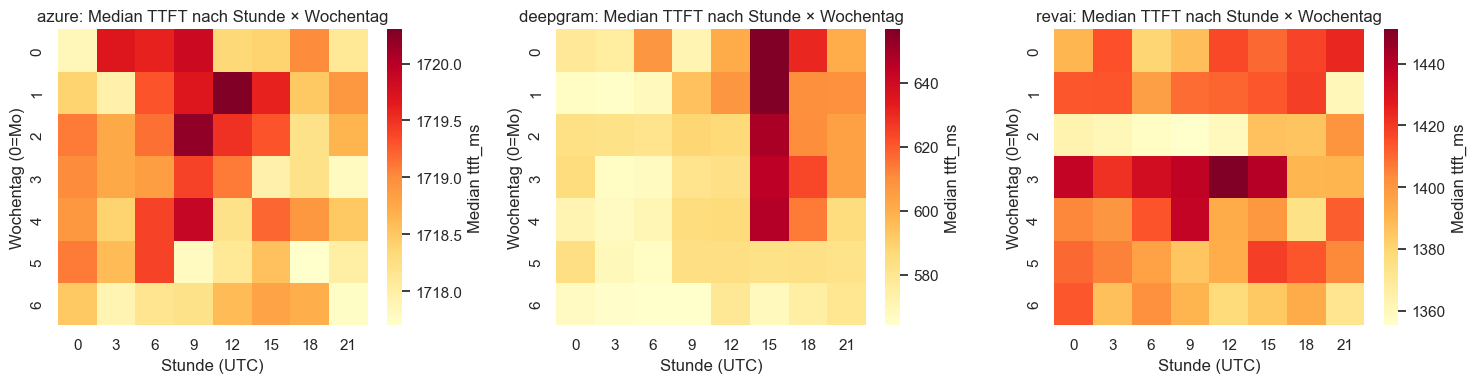

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, api in zip(axes, STT_ORDER):
    sub = stt[stt['api']==api]
    # weekday 0=Mo, 6=So
    pivot = sub.pivot_table(index='weekday', columns='hour', values='ttft_ms', aggfunc='median')
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', cbar_kws={'label':'Median ttft_ms'})
    ax.set_title(f'{api}: Median TTFT nach Stunde × Wochentag')
    ax.set_xlabel('Stunde (UTC)')
    ax.set_ylabel('Wochentag (0=Mo)')
plt.tight_layout()
save_figure(fig, '03_stt_heatmap_zeit')
plt.show()

  saved figures/03_stt/{png,pdf}/03_stt_drift


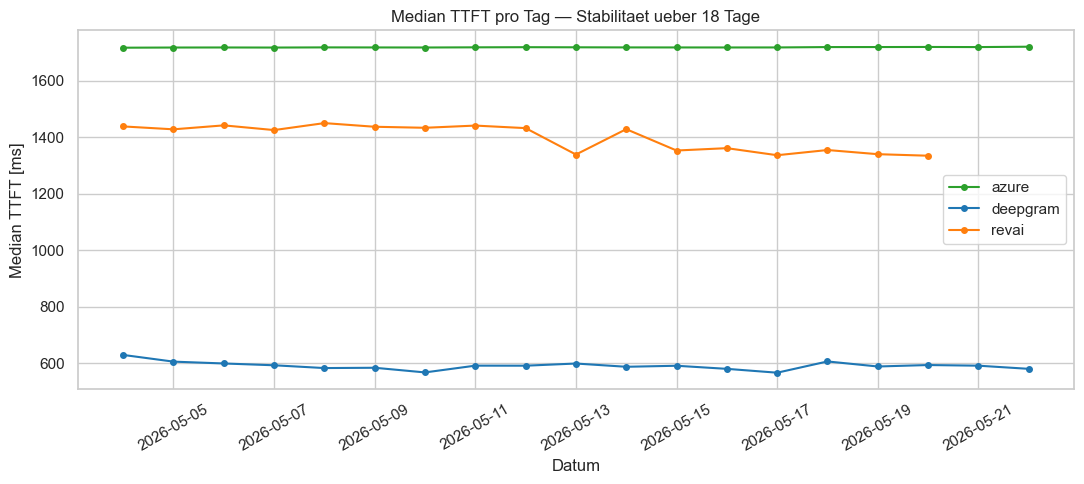

In [6]:
# Linienplot Median TTFT pro Tag
daily = stt.assign(date=lambda d: pd.to_datetime(d['ts']).dt.date)\
             .groupby(['api','date'])['ttft_ms'].median().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
for api in STT_ORDER:
    sub = daily[daily['api']==api].sort_values('date')
    ax.plot(sub['date'], sub['ttft_ms'], marker='o', markersize=4,
            label=api, color=PALETTE[api], linewidth=1.5)
ax.set_ylabel('Median TTFT [ms]')
ax.set_xlabel('Datum')
ax.set_title('Median TTFT pro Tag — Stabilitaet ueber 18 Tage')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
save_figure(fig, '03_stt_drift')
plt.show()

## 4. Warm-up-Analyse

**Frage:** Werden spaetere Runs innerhalb eines Slots schneller? Das wuerde auf TCP-Caching, DNS-Caching oder Connection-Reuse hindeuten — was eigentlich nicht passieren sollte, weil das Messdesign Cold-Start vorschreibt (jede Messung neue TCP+TLS-Verbindung).

**Erwartung:** Median TTFT pro `run` (0-99) sollte flach sein. Wenn ein Trend sichtbar wird (sinkend), ist die Cold-Start-Methodik verletzt.

  saved figures/03_stt/{png,pdf}/03_stt_warmup


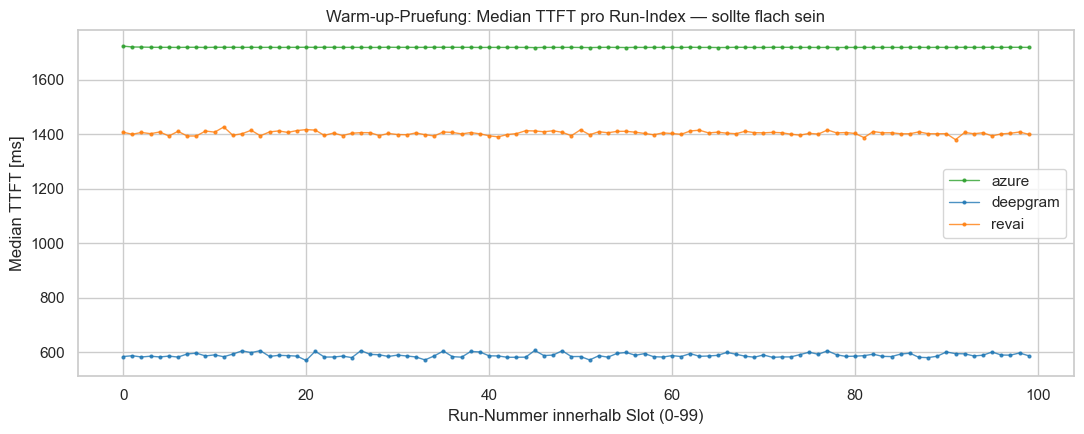

=== Linearer Trend Median(ttft) gegen run-Index ===
  azure      slope= -0.006 ms/run   p=0.001   R²=0.108
  deepgram   slope= +0.022 ms/run   p=0.421   R²=0.007
  revai      slope= -0.024 ms/run   p=0.325   R²=0.010


In [7]:
warmup = stt.dropna(subset=['run']).groupby(['api','run'])['ttft_ms'].median().reset_index()

fig, ax = plt.subplots(figsize=(11, 4.5))
for api in STT_ORDER:
    sub = warmup[warmup['api']==api].sort_values('run')
    ax.plot(sub['run'], sub['ttft_ms'], marker='.', markersize=4, linewidth=1,
            label=api, color=PALETTE[api], alpha=0.8)
ax.set_xlabel('Run-Nummer innerhalb Slot (0-99)')
ax.set_ylabel('Median TTFT [ms]')
ax.set_title('Warm-up-Pruefung: Median TTFT pro Run-Index — sollte flach sein')
ax.legend()
plt.tight_layout()
save_figure(fig, '03_stt_warmup')
plt.show()

# Numerischer Test: lineare Regression slope pro Provider
from scipy.stats import linregress
print('=== Linearer Trend Median(ttft) gegen run-Index ===')
for api in STT_ORDER:
    sub = warmup[warmup['api']==api]
    res = linregress(sub['run'], sub['ttft_ms'])
    print(f'  {api:10s} slope={res.slope:+7.3f} ms/run   p={res.pvalue:.3f}   R²={res.rvalue**2:.3f}')

## 5. Verbindungs-Overhead-Anteil: `connect_ms` vs `ttft_ms`

**Frage:** Wie viel der gesamten Cold-Start-Latenz (`connect_ms + ttft_ms`) entfaellt auf den reinen Verbindungsaufbau vs Server-Processing? Wenn ein Provider 80 % connect / 20 % processing hat, bringt EU-Hosting massive Verbesserung. Wenn 10 % connect / 90 % processing, ist Modell-Wahl wichtiger.

**Methodik-Hinweis (wichtig!):** Der Messcode (`measurements/layer3/stt_*.py`) misst
`connect_ms = t_ws_connected - t_ws_start` und
`ttft_ms = t_first_final - t_first_chunk`,
wobei `t_first_chunk` direkt nach `t_ws_connected` liegt. Die beiden Phasen sind also **sequenziell und disjunkt** — `ttft_ms` enthaelt **nicht** den Verbindungsaufbau, sondern misst ausschliesslich die Server-Processing-Phase. Die Gesamt-Cold-Start-Latenz bis zum ersten Transkript-Wort ist daher `connect_ms + ttft_ms`, und der Connect-Anteil ist `connect_ms / (connect_ms + ttft_ms)` (**nicht** `connect_ms / ttft_ms`).

=== Connect- vs Server-Anteil an der Gesamt-Cold-Start-Latenz ===
          connect_p50  ttft_p50  cold_start_total_p50_ms  connect_share_pct  server_share_pct
api                                                                                          
azure            48.4   1,718.7                  1,767.1                2.7              97.3
deepgram        437.0     587.0                  1,024.0               42.7              57.3
revai           592.7   1,404.1                  1,996.8               29.7              70.3


  saved figures/03_stt/{png,pdf}/03_stt_connect_anteil


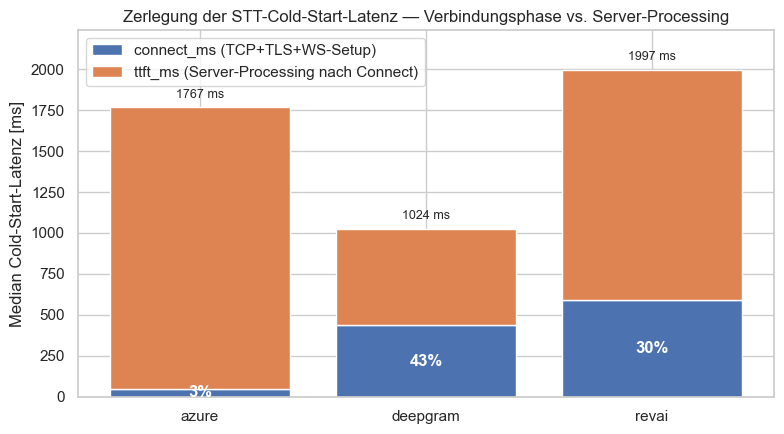

In [8]:
# Anteil-Tabelle
# Wichtig: connect_ms und ttft_ms sind sequenzielle, disjunkte Phasen (siehe Messcode).
# Die Gesamt-Cold-Start-Latenz ist connect_ms + ttft_ms. ttft_ms IST die Server-Processing-
# Phase nach Verbindungsaufbau — also NICHT (ttft - connect) wie eine fruehere Version hier
# berechnete. Der korrekte Connect-Anteil ist connect_ms / (connect_ms + ttft_ms).
anteil = stt.groupby('api').agg(
    connect_p50=('connect_ms','median'),
    ttft_p50=('ttft_ms','median'),  # = Server-Processing nach Connect
).round(1)
anteil['cold_start_total_p50_ms'] = (anteil['connect_p50'] + anteil['ttft_p50']).round(1)
anteil['connect_share_pct']        = (anteil['connect_p50'] / anteil['cold_start_total_p50_ms'] * 100).round(1)
anteil['server_share_pct']         = (anteil['ttft_p50']    / anteil['cold_start_total_p50_ms'] * 100).round(1)
anteil = anteil.reindex(STT_ORDER)
print('=== Connect- vs Server-Anteil an der Gesamt-Cold-Start-Latenz ===')
print(anteil.to_string())

# Stacked-Bar: connect_ms (Netzwerk) vs ttft_ms (Server-Processing)
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(STT_ORDER))
connect = anteil['connect_p50'].values
server  = anteil['ttft_p50'].values  # ttft_ms IST die Server-Processing-Phase
ax.bar(x, connect, label='connect_ms (TCP+TLS+WS-Setup)', color='#4c72b0')
ax.bar(x, server, bottom=connect, label='ttft_ms (Server-Processing nach Connect)', color='#dd8452')
ax.set_xticks(x)
ax.set_xticklabels(STT_ORDER)
ax.set_ylabel('Median Cold-Start-Latenz [ms]')
ax.set_title('Zerlegung der STT-Cold-Start-Latenz — Verbindungsphase vs. Server-Processing')
ax.legend(loc='upper left')
# Labels: Connect-Anteil in der blauen Bar, Gesamtsumme ueber den Bars
ymax = (connect + server).max()
for i, (c, s) in enumerate(zip(connect, server)):
    total = c + s
    pct   = c / total * 100
    ax.text(i, c/2,                f'{pct:.0f}%',     ha='center', va='center', color='white', fontweight='bold')
    ax.text(i, total + ymax*0.02,  f'{total:.0f} ms', ha='center', va='bottom',  fontsize=9)
ax.set_ylim(0, ymax * 1.12)
plt.tight_layout()
save_figure(fig, '03_stt_connect_anteil')
plt.show()

## 6. Hauptbefunde

### 6.1 Reihenfolge anders als erwartet — Engine schlaegt Netzwerk
Naive Erwartung (basierend auf NB 01): Azure-EU am schnellsten, Rev.ai US am langsamsten, Deepgram US dazwischen. **Realitaet:**

| Provider | connect p50 | ttft p50 (Server-Processing) | Cold-Start gesamt (connect + ttft) |
|----------|-----------:|----------------------------:|----------------------------------:|
| **deepgram** | 437 ms | **587 ms** (schnellster) | **1024 ms** (schnellster) |
| **revai**    | 593 ms | 1404 ms | 1997 ms |
| **azure**    |  48 ms | **1719 ms** (langsamster) | **1767 ms** (langsamster) |

Hinweis: `ttft_ms` misst gemaess Messcode die Phase **nach** dem Verbindungsaufbau (`t_first_chunk → t_first_final`) und ist damit direkt der Server-Processing-Anteil. Die user-perceived Cold-Start-Latenz bis zum ersten Transkript-Wort ist `connect_ms + ttft_ms`.

Deepgram gewinnt **trotz** US-Hosting wegen einer extrem effizienten Engine (Nova-3): nur 587 ms Server-Processing. Azure verliert **trotz** EU-Hosting wegen 1719 ms Server-Processing (Subscription-Lookup + Spracherkennungs-Engine).

**Forschungs-Implikation:** Die naive Annahme "EU-Region = niedrige Latenz" gilt nur fuer den Verbindungsaufbau, nicht fuer die user-perceived TTFT. Bei STT dominiert die Engine.

### 6.2 Zwei Latenz-Profile, drei Optimierungsstrategien
Aus dem connect/server-Verhaeltnis (jeweils Anteil an `connect_ms + ttft_ms`) ergeben sich verschiedene Hebel:

| Provider | Connect/Gesamt | Server/Gesamt | Bottleneck | Optimierungs-Hebel |
|----------|---------------:|--------------:|------------|--------------------|
| deepgram | 43 % | 57 % | Netzwerk dominant | EU-Region oder Persistent Connections → Cold-Start sinkt auf ~587 ms (= reines `ttft_ms`) |
| revai    | 30 % | 70 % | beide relevant | TLS 1.3 spart ~142 ms (1 RTT) + EU-Region + Modellwechsel |
| azure    |  3 % | 97 % | Server dominant | nur Modellwahl / API-Variante hilft (z.B. "Fast Transcription") |

### 6.3 Verteilungs-Charakteristik
- **Azure** ist extrem konsistent: std=14 ms bei ttft=1719 ms (CV<1%). Die Engine-Last ist server-gemanaged stabil.
- **Deepgram** ist variabler: std=380 ms bei ttft=587 ms (CV=65%). Vermutlich Anycast-Edge-Wechsel (siehe NB 01: 9 unique IPs).
- **Rev.ai** moderate Streuung: std=183 ms bei ttft=1404 ms (CV=13%).

### 6.4 Total_ms zeigt Streaming-Verhalten
- **Deepgram**: ttft=587 ms, total=4252 ms — sehr langes Tail nach erstem Token (Engine schickt mehrere `is_final`-Segmente bis Audio komplett verarbeitet).
- **Azure**: ttft=1719 ms, total=1768 ms — sehr kurzer Tail. Liefert vermutlich alles in einem Block.
- **Rev.ai**: ttft=1404 ms, total=2086 ms — moderater Tail (~700 ms).

Methodischer Hinweis: Unsere TTFT-Definition ist "erstes Transkript-Wort". Fuer Echtzeit-Anwendungen ist das die relevante Metrik. total_ms ist eher fuer Batch-Use-Cases interessant.

### 6.5 Warm-up: keiner — Cold-Start-Methodik bestaetigt
Lineare Regression Median(ttft) gegen run-Index liefert fuer alle drei Provider slopes nahe 0 (|slope| < 0.03 ms/run). Bei azure ist der Trend statistisch signifikant (p=0.001), aber praktisch irrelevant (-0.006 ms/run × 100 runs = -0.6 ms). Cold-Start-Methodik ist gewahrt, kein Connection-Pooling, kein TCP-Caching-Artefakt.

### 6.6 Zeitliche Stabilitaet — keine Tageszeit-Variation
Heatmaps Stunde × Wochentag zeigen fuer alle drei Provider eine flache Verteilung. Keine signifikante Variation durch US-Office-Hours oder EU-Spitzenzeiten. Das spricht fuer global gut dimensionierte Infrastruktur — keine spuerbare Ueberlast-Phase.

### 6.7 Drift ueber 18 Tage
Linienplot Median TTFT pro Tag zeigt fuer Azure und Rev.ai sehr stabile Werte. Bei Deepgram ist eine leichte Tag-zu-Tag-Variation sichtbar (±30 ms) — vermutlich Anycast-Edge-Wechsel zwischen verschiedenen 123NET-PoPs.

### 6.8 Vorbereitung fuer NB 06 (Cross-Layer-Korrelation)
Das `connect_ms`-Verhalten ist klar netzwerk-bestimmt und in NB 06 ueber das Modell `connect ≈ N_RTTs × ping + k` mit r=0.999 verifiziert:
- **Deepgram** STT: `connect ≈ 3 × ping + 18.5 ms` (3 RTTs: TCP + TLS 1.3 + WS-Upgrade)
- **Azure** STT:    `connect ≈ 3 × ping + 17.3 ms` (gleiche 3 RTTs, nur ping viel kleiner)
- **Rev.ai** STT:   `connect ≈ 4 × ping + 25.7 ms` (TLS 1.2 → +1 RTT, gemessene Penalty ~142 ms)

Das `ttft_ms` korreliert dagegen **nicht** linear mit RTT — es ist server-/engine-dominiert. Das ist der zentrale Cross-Layer-Befund: Layer-1-Eigenschaften erklaeren `connect_ms` zuverlaessig, aber **nicht** `ttft_ms`. Fuer die user-perceived Latenz dominieren bei STT die Engine-Eigenschaften.